In [1]:
from pyfiles.preamble import *
enable_autoreload()

# EnergyPLAN output analysis

This notebook reads model output for both scenarios and summarises results across two dimensions: monthly production and storage profiles, and the full 8760-hour dispatch. All data are loaded from the parquet files produced by `3_run_all.ipynb`.

**Contents:**
1. **Time-series by month** — monthly production, storage, and demand profiles
2. **Time-series by hour** — full hourly dispatch for selected variables

## 1. Time-series by month

Monthly production and storage profiles for both scenarios. Each panel shows one technology across the twelve months of the calculation year; the two lines distinguish the base and shock case.

*Core production variables — electricity from VRE, nuclear, thermal, and net exchange.*

In [2]:
# 1. build df (monthly)
dfs_months_2 = [build_frames.timeseries_months(f) for f in var_groups.shock]

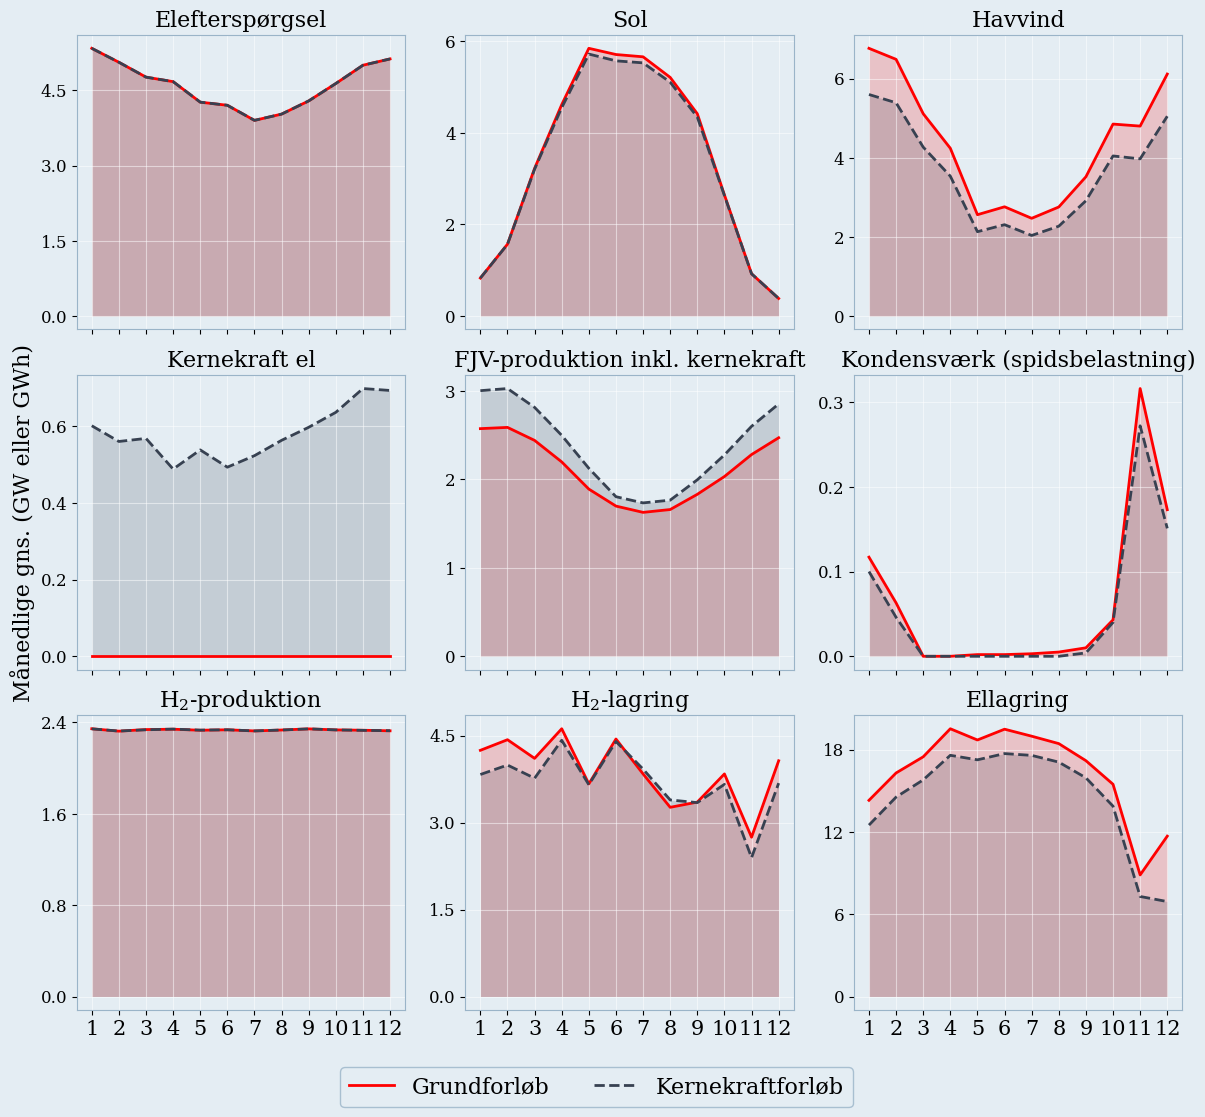

(<Figure size 1200x1100 with 9 Axes>,
 array([<Axes: title={'center': 'Elefterspørgsel'}>,
        <Axes: title={'center': 'Sol'}>,
        <Axes: title={'center': 'Havvind'}>,
        <Axes: title={'center': 'Kernekraft el'}, ylabel='Månedlige gns. (GW eller GWh)'>,
        <Axes: title={'center': 'FJV-produktion inkl. kernekraft'}>,
        <Axes: title={'center': 'Kondensværk (spidsbelastning)'}>,
        <Axes: title={'center': '$H_2$-produktion'}>,
        <Axes: title={'center': '$H_2$-lagring'}>,
        <Axes: title={'center': 'Ellagring'}>], dtype=object))

In [3]:
overview_fig.plot_metrics_months_grid(
    dfs         = dfs_months_2, 
    plots       = var_groups.core_vars, 
    case_labels = var_groups.all_cases_dict, 
    tech_labels = var_groups.tech_labels,
    bg_color    = "#e4edf3",   
    fill_alpha  = 0.18,
    savepath    = "0_figurs/månedlig_oversigt.png",
    dpi         = 300,
)

## 2. Time-series by hour

Full 8760-hour dispatch for selected variables. Hourly resolution reveals peak behaviour, curtailment windows, and storage cycling patterns that monthly averages mask.

*Load hourly output for both scenarios, then plot selected variables.*

In [4]:
# 1. build df
dfs = [build_frames.timeseries_hourly(f) for f in var_groups.shock]

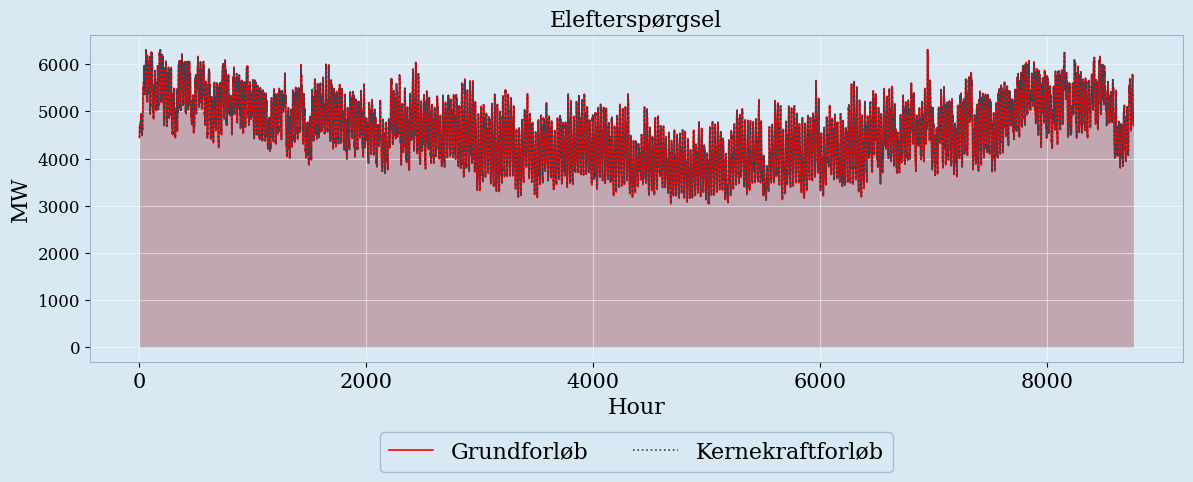

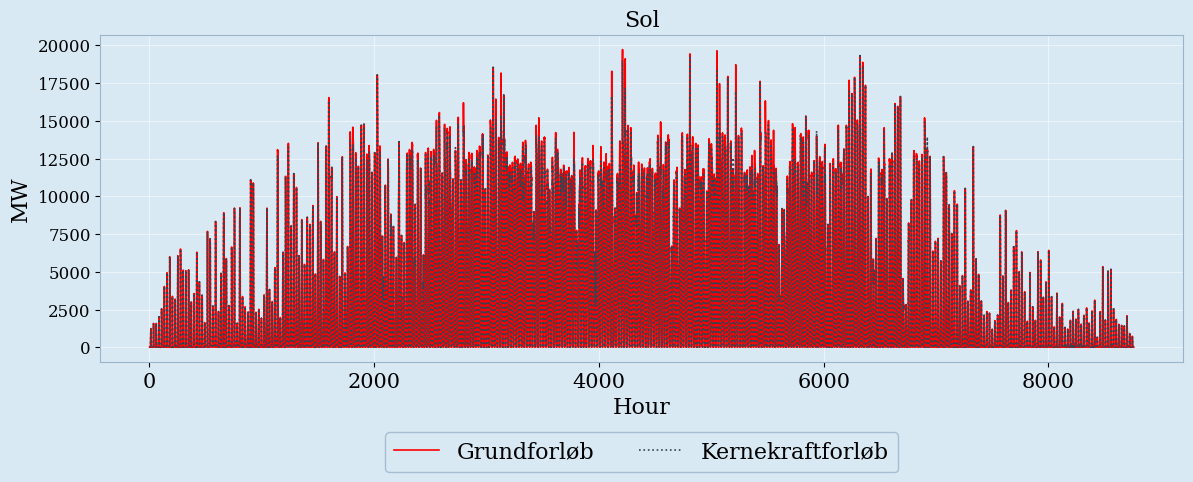

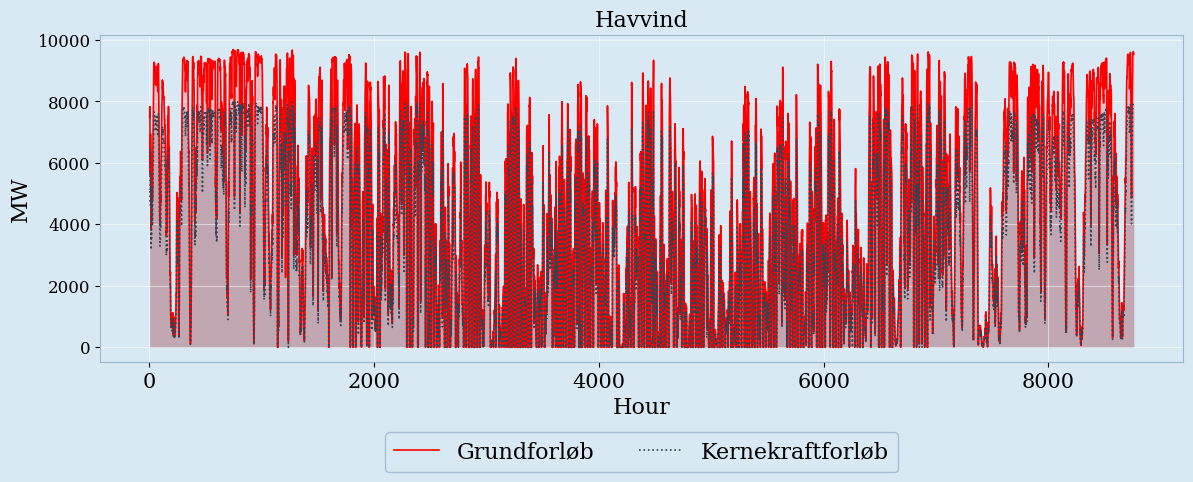

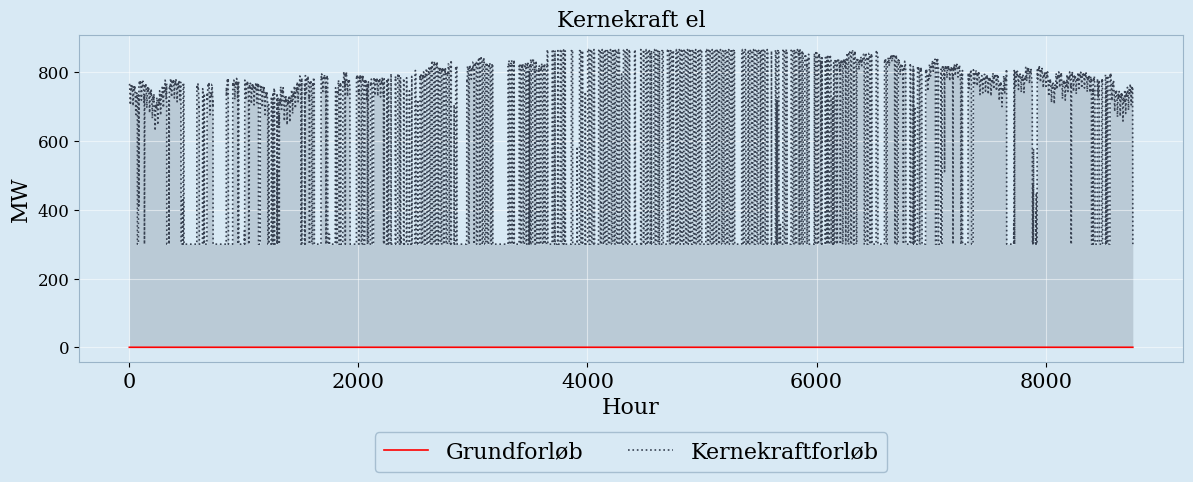

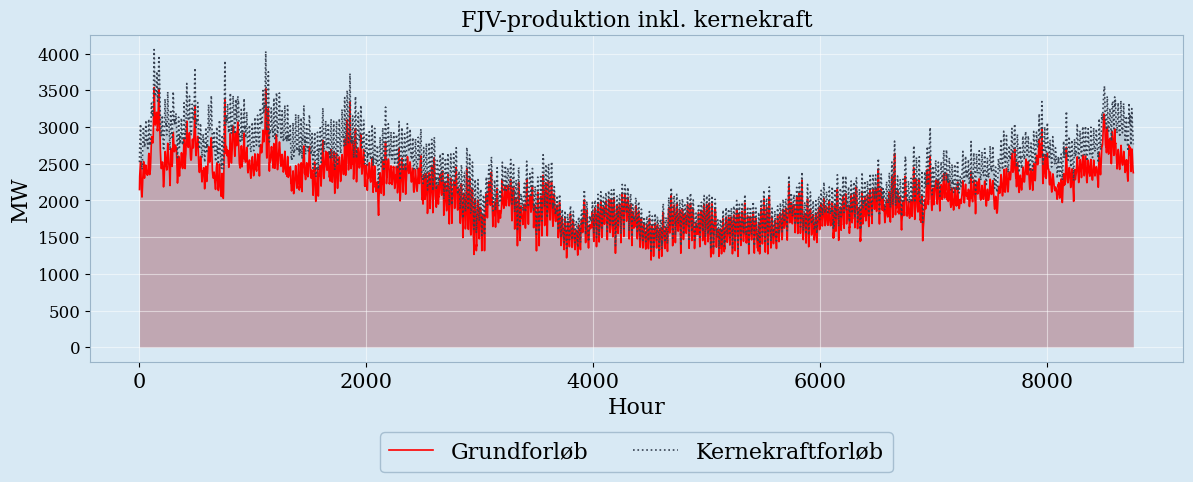

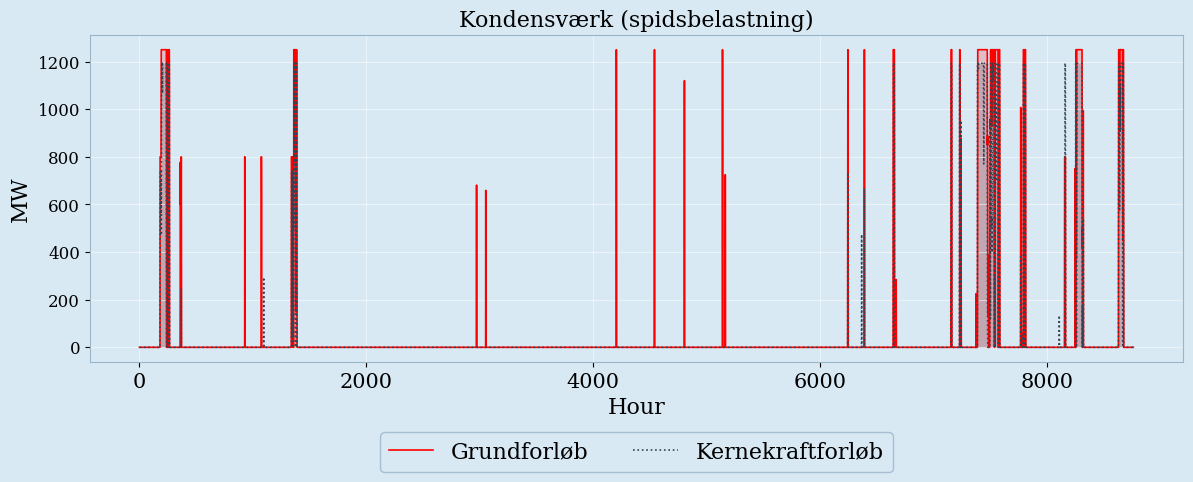

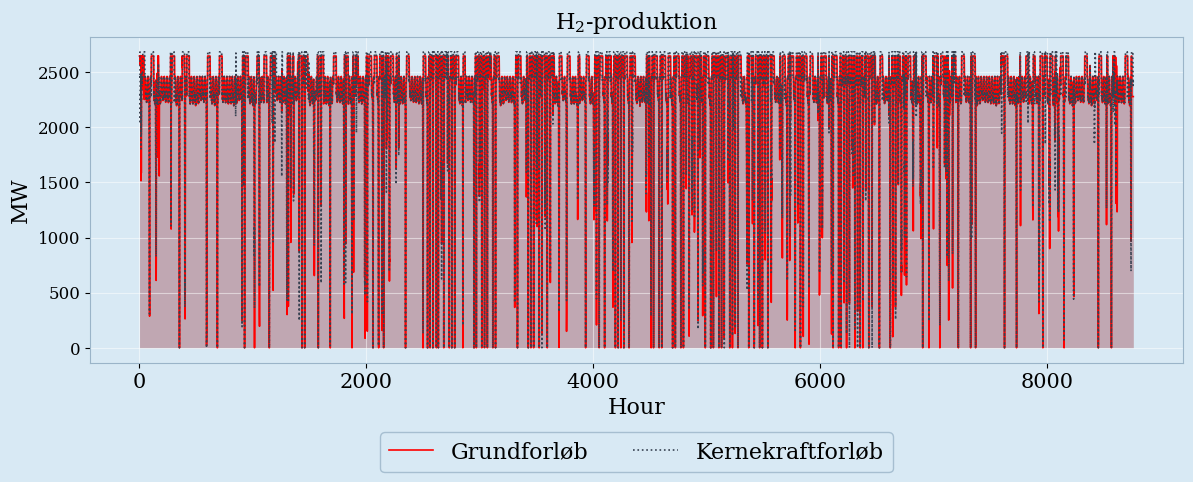

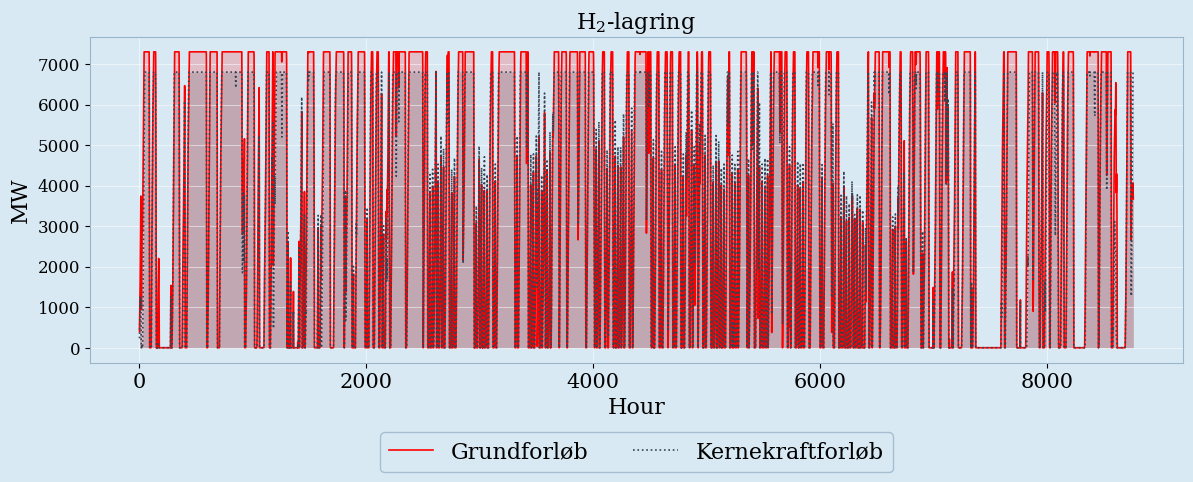

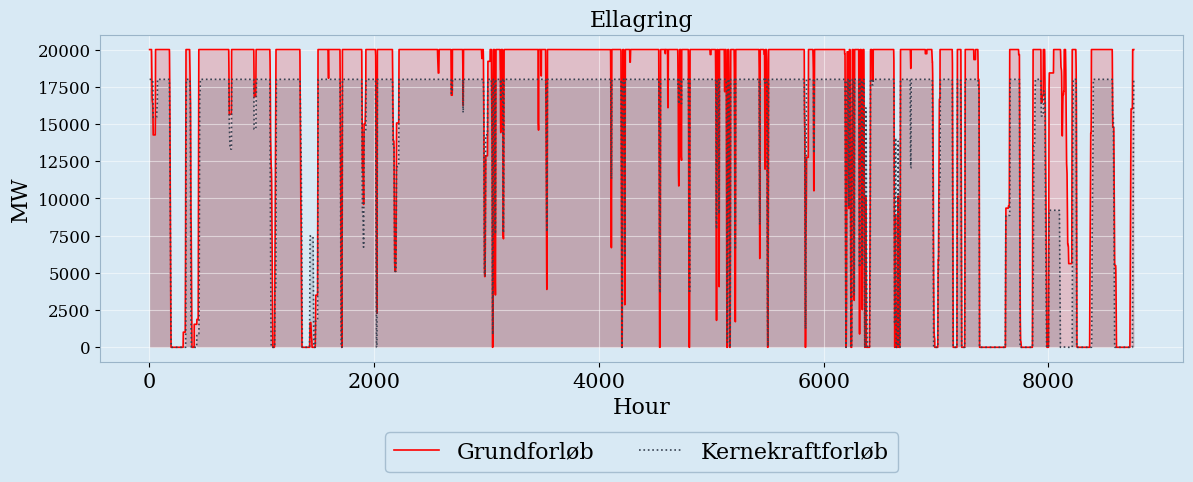

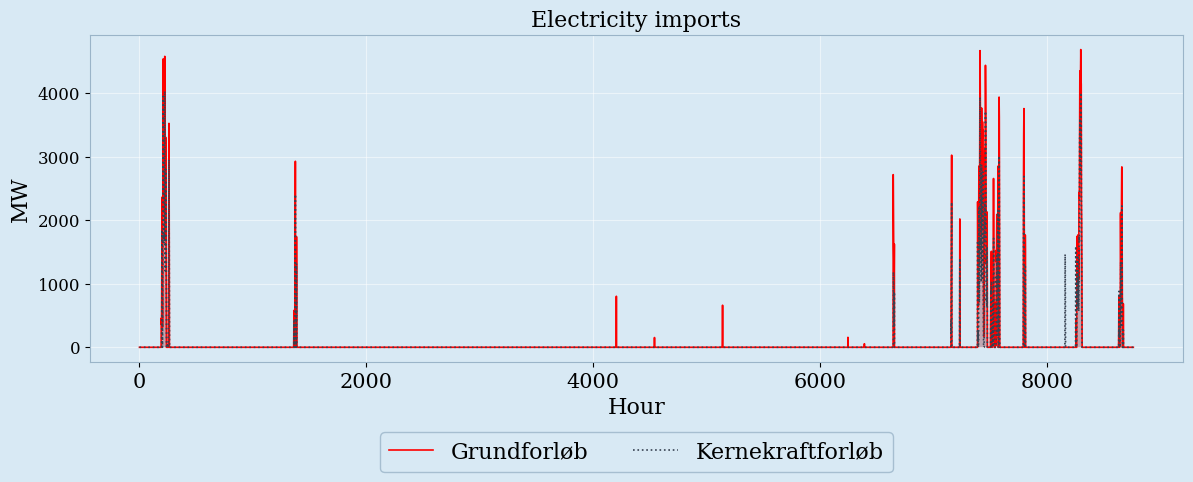

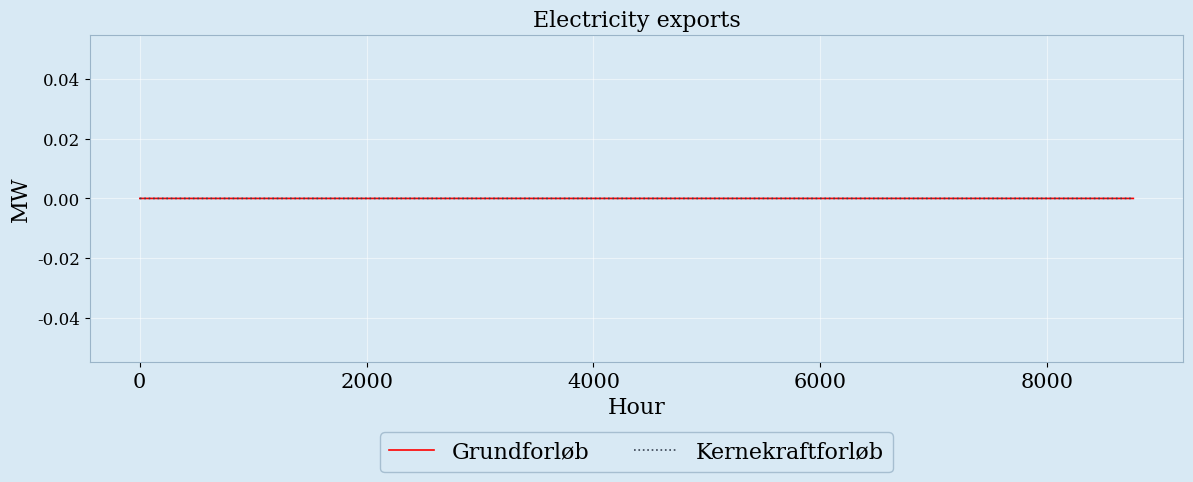

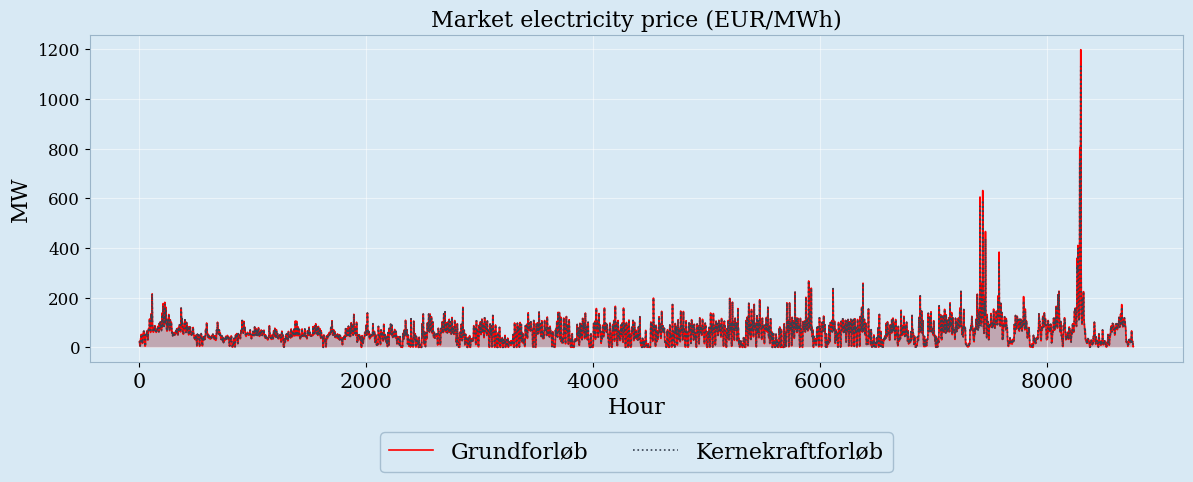

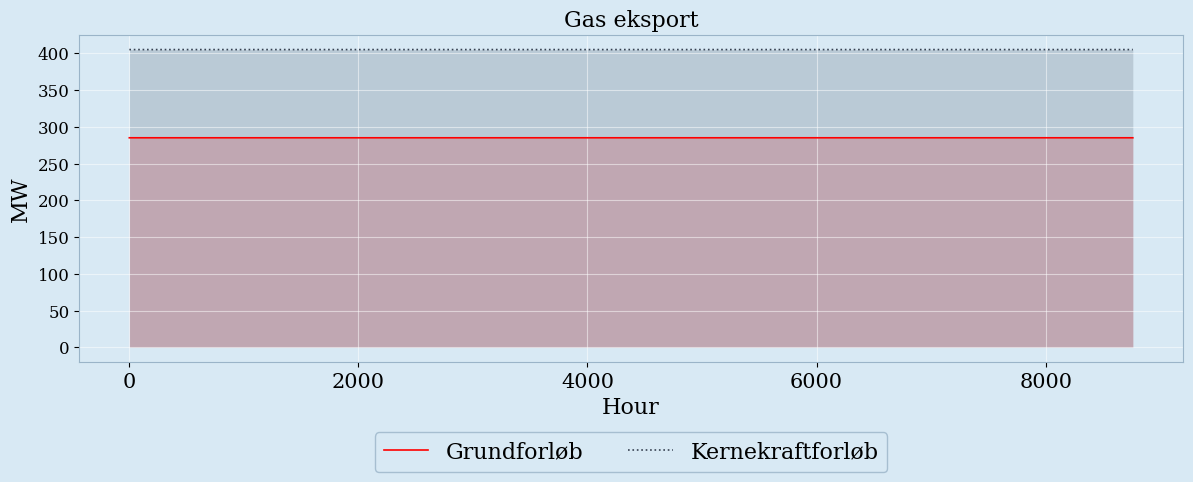

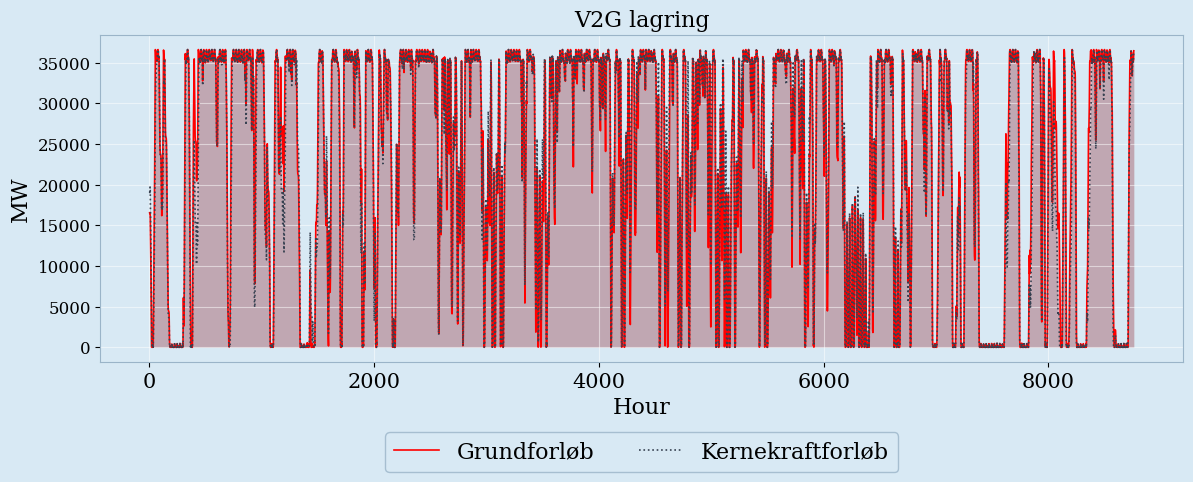

In [5]:
# 2. plot
build_frames.plot_metrics(
    dfs         = dfs,
    plots       = (var_groups.core_vars + 
                   ['Import_Electr.','Export_Electr.',
                    'InMarket_Prices','Export_Gas','V2G_Storage']),
    case_labels = var_groups.all_cases_dict,
    tech_labels = var_groups.tech_labels,
    bg_color    = "#d8e9f4",
    fill_alpha  = 0.18,
    save_dir    = "0_figurs/hourly",
)